<a href="https://colab.research.google.com/github/NVishnevskaya/bubbles/blob/main/bubble_viz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Кластеризация мыльных пузырей </h1>

**Задача**: реализовать алгоритм, который бы делил множество точек (центров пузырей) на группы + создать болванку для качественного графика

**Пожелания по группам и алгоритму**

1.   Кластер не содержит пропуски
2.   Группа содержит больше 3 пузырей
3.   Алгоритм определяет количество групп автоматически
4.   Алгоритм определяет шумы



# <h2> Импорты и константы </h2>

In [1]:
!pip install alphashape

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from random import uniform, randint
# это для легенды
import matplotlib.lines as mlines
from matplotlib.colors import Normalize

In [3]:
# для кластеризации
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN
# для отображения кластеров - отрисовки их контуров
import alphashape
# умный расчет расстояний
from scipy.spatial.distance import cdist
from scipy.spatial import distance

In [4]:
# множитель для отрисовки, так как размер там передается в типографских точках
conv_coef = 1 / 0.376 * 100

# <h2> Функции для генерации и отрисовки сетки </h2>

In [5]:
# создать сетку из пузырей в прямоугольнике
def build_net(N: int, M: int, R: float, addition: float,
              perc: float) -> np.ndarray:
    """Return centers of circles, which are placed in rectangle(N x M).

    Parameter
    ---------
    N: int
        quantity of circles in a column
    M: int
        quantity of circles in a row
    R: float
        radius of circle, equal for all of them
    addition: float
        addition to shift between circles
    perc:
        fraction of space in percent

    Return
    -------
    np.ndarray (np.array([np.array([1., 2.]), np.array([3., 4.])])
        numpy array with coordinates of centers
    """
    # задаю y, чтобы пузырь был рядом со стенкой
    cur_y = uniform(R, R + addition)
    # список с координатами центров кругов
    dots_list = []
    # обход строк
    for _ in range(N):
        # координата по x, чтобы пузырь был рядом со стенкой
        cur_x = uniform(R, R + addition)
        # обход столбцов
        for _ in range(M):
            # условие, чтобы установить необходимую долю пустот
            if randint(1, 100) <= perc:
                # обеспечиваю сдвиг по x
                cur_x += 2 * uniform(R - addition, R + addition)
                continue
            # вношу координаты в список точек
            dots_list.append(np.array((cur_x, cur_y)))
            # сдвиг по x
            cur_x += 2 * uniform(R - addition, R + addition)
        # обеспечиваю сдвиг по y
        cur_y += 2 * uniform(R, R + addition)
    # возвращаю списки
    return np.array(dots_list)

In [6]:
def define_canvas_sizes(dots: np.ndarray,
                        R: float) -> tuple:
    """Return recommended size for matplotlib.figure

    Parameter
    ---------
    dots: np.ndarray
        array in which calculations are based
    R: float
        radius (equal to all circles)

    Return
    ------
    tuple(np.float64, np.float64)
        recommended size
    """
    xs, ys = dots[:, 0], dots[:, 1]
    x_size = (np.max(xs) - np.min(xs)) / (2 * R)
    y_size = (np.max(ys) - np.min(ys)) / (2 * R)
    return np.round(x_size, 2) / 4, np.round(y_size, 2) / 4

In [7]:
# отрисовка сетки с пузырьками
def show_net(dots: np.ndarray, R: float, title: str=None, alpha: float=0.8,
             bubble_colors=None, color_map: str="gnuplot2_r",
             create_figure: bool=True) -> None:
    """ Create plot with circles

    Parameter
    ---------
    dots: np.ndarray
        centers of circles
    R: float
        radius (equal to all circles)
    title: str
        bold title of the plot
    alpha: float
        transparency of circles
    bubble colors: nd.array
        array with colors of circles / numbers of groups
    color map: str
        name of color map
    create figure: bool
        to create new figure or not
    Return
    ------
    None
    """
    str_q, col_q = define_canvas_sizes(dots, R)
    # это для правильного масштаба
    if create_figure:
        plt.figure(figsize=(col_q, str_q))
    # отображение пузырьков в виде окружностей
    xs, ys = dots[:, 0], dots[:, 1]
    plt.scatter(xs, ys, s=R *conv_coef, marker=".", linewidths=1,
            alpha=alpha, edgecolors="black", c=bubble_colors, cmap=color_map)
    # отображение центров окружностей
    plt.scatter(xs, ys, c="black", s=1, alpha=alpha)
    if title is not None:
        plt.title(title, weight="bold")

In [8]:
# параметры для проверки функций
cur_n, cur_m = 30, 30
cur_r = 3
percent_of_space = 20

/tmp/ipython-input-7-1279800378.py:33: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(xs, ys, s=R *conv_coef, marker=".", linewidths=1,


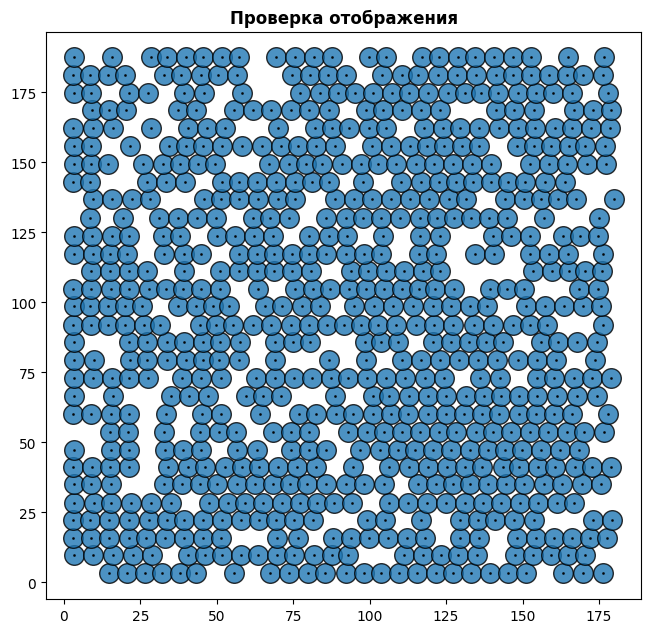

In [9]:
# отрисовка с фокусами для отображения
dots_list = build_net(cur_n, cur_m, cur_r, 0.1 * cur_r,
                                    percent_of_space)
show_net(dots_list, cur_r, title="Проверка отображения")

# <h2> Функции для расчета пустот </h2>

In [10]:
def calc_circle_intersec(x1: float, y1: float, x2: float, y2: float,
                         r1: float, r2: float) -> float:
    """ Return an area of intersection for two circles

    Parameter
    ---------
    x1: float
        x-coordinate of the first circle
    y1: float
        y-coordinate of the first circle
    x2: float
        x-coordinate of the second circle
    y2: float
        y-coordinate of the second circle
    r1:
        radius of the first circle
    r2:
        radius of the second circle
    Return
    ------
    float
        area of intersection
    """
    # расстояния между центрами окружностей
    d = ((x1 - x2) ** 2 + (y1 - y2) ** 2) ** 0.5
    if d >= (r1 + r2):
        return 0
    # вспомогательные углы из теоремы косинусов
    f1 = 2 * np.arccos((r1 ** 2 - r2 ** 2 + d ** 2) / (2 * r1 * d))
    f2 = 2 * np.arccos((r2 ** 2 - r1 ** 2 + d ** 2) / (2 * r2 * d))
    # продолжение, пока вывод формулы не смотрела, но 100% работает
    s1 = r1 ** 2 * (f1 - np.sin(f1)) / 2
    s2 = r2 ** 2 * (f2 - np.sin(f2)) / 2
    return s1 + s2

# <h2> Алгоритмы кластеризации </h2>

<h3> Kmeans </h3>

In [11]:
# разбиение по группам kmeans - халявная функция, чтобы продемонстрировать:
#   kmeans не подходит
def get_kmeans_prediction(dots: np.ndarray, q_clusters: int) -> np.ndarray:
    """ Return number of groups for each dot in dots, based on kmeans

    Parameter
    ---------
    dots: np.ndarray
        centers of circles
    q_clusters:
        quantity of clusters

    Return
    ------
    np.ndarray
        kmeans prediction for each of the dot
    """
    # groups_q = int(N * M * (per_of_space / 100))
    kmeans = KMeans(n_clusters=q_clusters, n_init="auto").fit(dots)
    predicted = kmeans.labels_
    return predicted

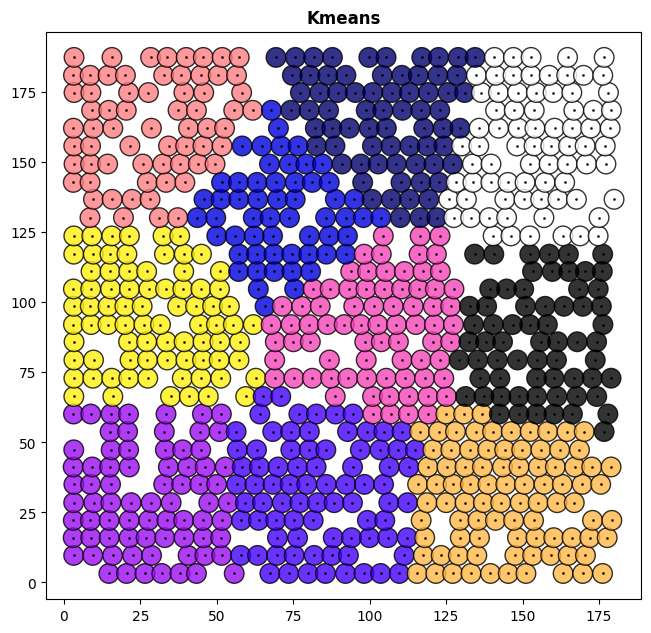

In [12]:
k_preds = get_kmeans_prediction(dots_list, 10)
show_net(dots_list, cur_r, title="Kmeans",
         bubble_colors=k_preds)

<h3> DBSCAN + модификация </h3>


**Как работает DBSCAN?**

-> Dencity-based Spacial Clustering of Applications with Noises

Параметры:
- min_samples - количество соседей у ключевой точки
- epsilon - окрестность, в которой проходит соседей для точки

Виды точек:
*   ключевые - точки, у которых есть min_samples соседей или больше, которые нахоятся в окрестности epsilon
*   граничные - точки, которые находятся в окрестности ключевых, но имеют соседей меньше, чем min_samples
*  одиночные / шумовые - точки, у которых соседей меньше, чем min_samples, а также не попадают в окрестность ключевой точки

Алгоритм:
1. Берем произвольную непосещенную точку из набора данных
2. Определяем тип точки
3. Если точка НЕ ключевая, то отмечаем ее, как шумовую -> 1
4. Если точка ключевая, то создаем новый кластер с этой точкой
5. Итеративно проверяем соседей точки -> 1

Идея: маленькие группы (1 - 3 пузыря) определяем, как шум



Закоментированно построение графика для определения eps


```
from sklearn.neighbors import NearestNeighbors

neibs = NearestNeighbors(n_neighbors=5)
neibs_fit = neibs.fit(new_dots)
dist, inds = neibs_fit.kneighbors(new_dots)
k_dists = sorted(dist[:, 4])
plt.grid("light")
plt.plot(k_dists)
```




In [13]:
# получаем состав группы по id с переключателем
def get_group_info(dots: np.ndarray, preds: np.ndarray,
                   group_id: int, return_indexes: bool=True) -> np.array:
    """ Return numpy array with coordinates of dots with group_id

    Parameter
    ---------
    dots: np.ndarray
        coordinates of circles centers
    preds: np.ndarray
        number of group for each circle
    group_id: int
        required id of group
    return_indexes: bool
        if True - function return suitable indexes
        else - return suitable coordinates

    Return
    ------
    np.ndarray
        coordinates of dots with group_number = group_id
    """
    indexes = tuple(filter(lambda i: preds[i] == group_id,
                               range(len(dots))))
    if return_indexes:
        return indexes

    group_dots = np.array(list(map(lambda i: dots[i], indexes)))
    return group_dots


In [14]:
# получить распределение на кластеры dbscan
def get_dbscan_prediction(dots: np.ndarray, eps: float, min_samples: int
                          , modificated: bool=False,
                          min_cluster_size: int=4) -> np.ndarray:
    """ Return distribution of groups for dots by dbscan

    Parameter
    ---------
    dots: np.ndarray
        coordinates of circles
    eps: float
        diamiter for checking neigbhors
    min_samples: int
        minimal number of neigbhors for dot to become key point
    modificated: bool
        turn modification: all groups smaller than min_cluster_size'll be inter-
            preted as noises
    min_cluster_size: int
        minimal quantity of dots in the cluster

    Return
    np.ndarray
    array with numbers of the groups for each circles
    ------
    """
    # настроенный алгоритм
    clusters = DBSCAN(eps=eps, min_samples=min_samples,).fit(dots)
    # номера групп
    predictions = list(clusters.labels_)

    # эта примочка, чтобы выявленные группы были с размерами, начиная с
    #       min_cluster_size; мелкие кластеры определяем как шум
    if modificated:
        for group_number in set(predictions):
            # пока подумаю оставлять или нет
            if group_number == -1:
                pass
            # список индексов пузырей, у которых номер группы - group_number
            indexes = get_group_info(dots, predictions, group_number)
            # проверка численности группы
            if len(indexes) < min_cluster_size:
                # переделываю в шум
                for index_to_fix in indexes:
                    predictions[index_to_fix] = -1
    # номера групп
    return predictions

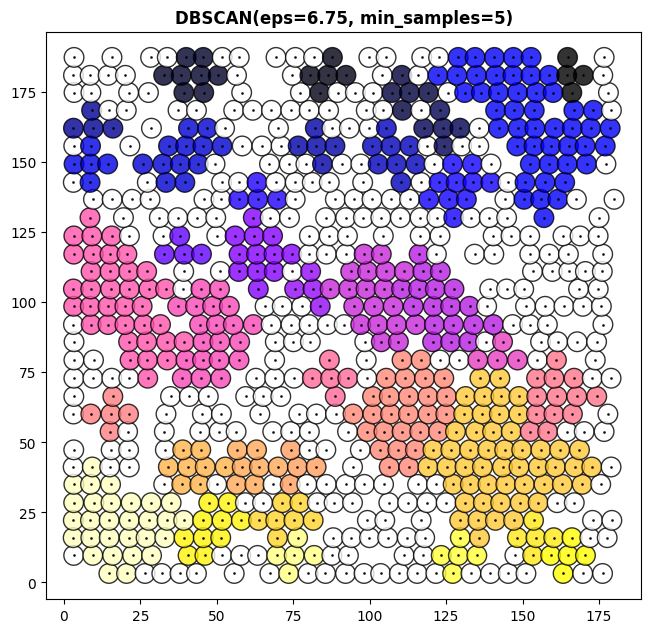

In [15]:
# параметры + запуск dbscan
cur_eps_coef = 2.25
cur_ms = 5
dbscan_preds = get_dbscan_prediction(dots_list, cur_eps_coef * cur_r, cur_ms,
                                     modificated=True)
# визуализация
show_net(dots_list, cur_r,
         bubble_colors=dbscan_preds,
         title=f"DBSCAN(eps={np.round(cur_eps_coef * cur_r, 2)}, min_samples={cur_ms})")

# <h3> Отрисовка с контурами кластеров </h3>

In [16]:
def expand_dots(centers: np.ndarray, R: float) -> np.array:
    """ Return corrected coords to build polygon based on tangent points

    Parameter
    ---------
    centers: np.ndarray
        coordinates of the centers of the circles
    R: float
        radius of the circles

    Return
    np.array
        new coordinates of dots
    ------
    """
    centers = np.asarray(centers)
    center_of_mass = np.mean(centers, axis=0)
    expanded_points = []
    for center in centers:
        direction = center - center_of_mass

        if np.linalg.norm(direction) > 1e-6:
            direction = direction / np.linalg.norm(direction)

        expanded_point = center + direction * R
        expanded_points.append(expanded_point)

    return np.array(expanded_points)

In [17]:
def get_polygon_for_cluster(dots: np.ndarray, group_ids: np.ndarray,
                            group_id: int, lower_border: int=4,
                            shape_alpha: float=0.2, optimize: bool=False,
                            to_expand_dots: bool=False,
                            r_val: float=0) -> alphashape.alphashape:
    """ Return polygon object for dots, included in group with group_id

    Parameter
    ---------
    dots: np.ndarray
        coordinates of the centers of the circles
    group_ids: np.ndarray
        numbers of the groups for each circle
    group_id: int
        id of the group to process it
    lower_border: int
        minimal quantity of dots to create polygon
    shape_alpha:
        special parameter to control polygon's shape
        shape_alpha ~ 0 -> borders of polygon will be exact
        shape_alpha ~ 10 -> polygon'll have convex contour
    optimize: bool
        switcher of optimization (if optimize=bool - choose shape_alpha
            automatically)
    to_expand_dots: bool
        if switched - polygon will be based on tangent points
    r_val: float
        radius of circles (equal for each circle)

    Return
    alphashape.alphashape
        polygon object from alphashape
    """
    # отбор точек с номером группы group_number
    dots_in_the_group = np.copy(get_group_info(dots, group_ids, group_id,
                                       return_indexes=False))
    # отобразить группы с 1 - 3 пузярями - проблемно
    if len(dots_in_the_group) < lower_border:
        return None
    # коррекция контура
    if to_expand_dots:
        dots_in_the_group = expand_dots(dots_in_the_group, r_val)
    # подбор коэффициента alpha (0 (уходим в детали) - 1 (выпуклая фигура))
    if optimize:
        # эмпирическое правило
        pairwise_dist = distance.pdist(dots_in_the_group)
        alpha = np.percentile(pairwise_dist, 5)
        opt_par = 1 / alpha
    else:
        opt_par = shape_alpha
    # чтобы не ломалось на hdbscan
    try:
        alpha_shape = alphashape.alphashape(dots_in_the_group, opt_par)
        if alpha_shape.geom_type == "Polygon":
            return alpha_shape
    except IndexError:
        pass

    return None


In [18]:
# получить список полиномов для переданного разбиения
def get_polygons_for_clusters(dots: np.ndarray, group_labels: np.ndarray,
                              lower_border: int=4,
                              shape_alpha: float=0.2, optimize: bool=False,
                              to_expand_dots: bool=False,
                              r_val: float=0) -> alphashape.alphashape:
    """ Generate sequance of polygons for accepted groups

    See description of get_polygon_for_cluster
    """
    # убираю шумы
    fixed_group_labels = set(group_labels) - set([-1])
    # перебор номеров групп
    for group_number in set(fixed_group_labels):
        cur_pol = get_polygon_for_cluster(dots, group_labels, group_number,
                                          lower_border=lower_border,
                                          shape_alpha=shape_alpha,
                                          optimize=optimize,
                                          to_expand_dots=to_expand_dots,
                                          r_val=r_val)
        if cur_pol != None:
            yield cur_pol
            del cur_pol

In [19]:
# отрисовка кластеров с контурами
def show_net_with_polygons(dots: np.ndarray, R: float, title: str=None,
                           bubble_colors: np.ndarray=None,
                           color_map: str="gnuplot2_r", pol_color: str="red",
                           legend_dict: dict=False, shape_alpha: float=0.2,
                           alpha: float=0.8, optimize: bool=False,
                           legend_tittle: str="Легенда",
                           to_expand_dots: bool=False) -> None:
    """
    Show plot with circles and contours of clusters

    Parameter
    ---------
    dots: np.ndarray
        coordinates of the centers of the circles
    R: float
        radius (equal for each circle)
    title: str
        bold tittle of the plot
    bubble_colors: np.ndarray
        array with group ids
    color_map: str
        name of the palette
    pol_color: str
        name of the color for contour of the polygon
    legend_dict: dict
        info for each of the group
    shape_alpha: float
        special coefficient to control shape of the contour
    alpha: float
        transperancy of the circles
    optimize: bool
        use auto choosing of shape_alpha
    legend_tittle: str
        title for the legend block
    to_expand_dots: bool
        if switched contours of clusters will be based on tangent points

    Return
    ------
    None
    """
    dots = np.copy(dots)
    plt.clf()
    # к сожалению, костыль
    str_q, col_q = define_canvas_sizes(dots, R)
    fig, ax = plt.subplots(figsize=(col_q, str_q))
    # отрисовка сетки
    show_net(dots, R, title, alpha,
             bubble_colors, color_map, create_figure=False)
    # получим список полиномов
    pols = get_polygons_for_clusters(dots, bubble_colors, lower_border=4,
                                     shape_alpha=shape_alpha, optimize=optimize,
                                     to_expand_dots=to_expand_dots, r_val=R)
    # перебор полигонов
    for pol in pols:
        # отрисуем контур полигона
        ax.plot(*pol.exterior.coords.xy, color=pol_color)

    # палитра
    cmap = plt.get_cmap(color_map)
    norm = Normalize(vmin=min(bubble_colors), vmax=max(bubble_colors))


    # отображение легенды
    if legend_dict:

        group_colors = dict()

        for group_id in np.unique(bubble_colors):
            group_colors[group_id] = cmap(norm(group_id))

        legend_elements = [
            mlines.Line2D([], [],
                  marker='o',
                  color='w',  # цвет линии (невидим)
                  label=legend_dict[group_id],
                  markerfacecolor=color,  # цвет маркера
                  markersize=10,
                  markeredgecolor='black')
            for group_id, color in group_colors.items()
        ]

        legend = ax.legend(
            handles=legend_elements,
            title=legend_tittle,
            bbox_to_anchor=(1.05, 1),
            loc='upper left',
            borderaxespad=0.,

        )

<Figure size 640x480 with 0 Axes>

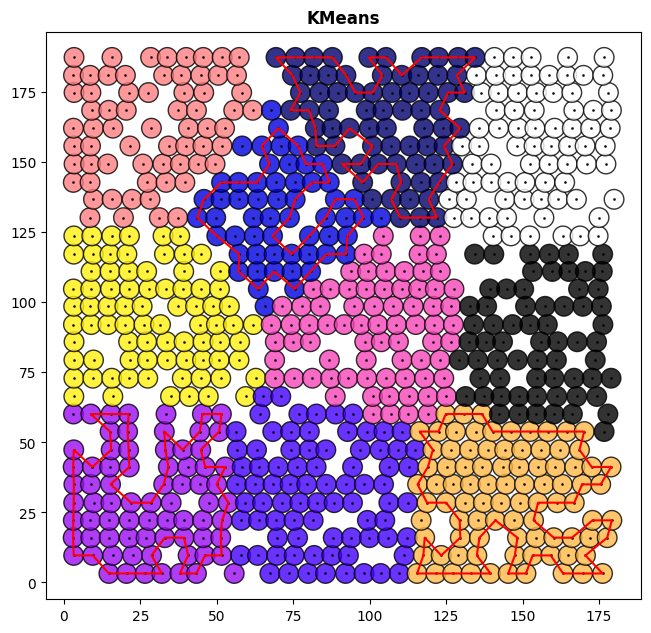

In [20]:
show_net_with_polygons(dots_list, cur_r, title="KMeans",
                       bubble_colors=k_preds)

<Figure size 640x480 with 0 Axes>

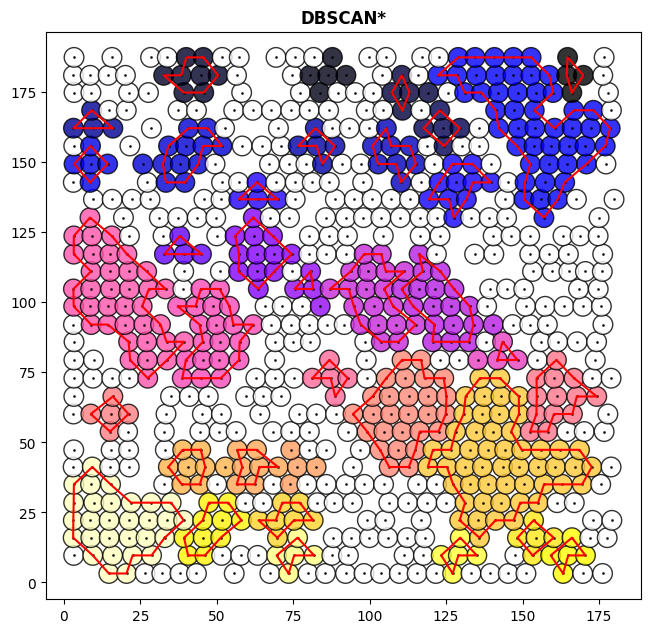

In [21]:
show_net_with_polygons(dots_list, cur_r, title="DBSCAN*",
                       bubble_colors=dbscan_preds)

<h3> HDBSCAN </h3>

In [22]:
# запускаем HDBSCAN
def get_hdbscan_prediction(dots: np.ndarray, min_samples: int=5,
                           min_cluster_size: int=6,
                           max_cluster_size: int=22,
                           alpha: float=0.6) -> np.ndarray:
    """ Return distribution of group numbers for dots

    Parameter
    ---------
    dots: np.ndarray
        coordinates of centers of the circles
    min_cluster_size: int
        minimal quantity of dots to form cluster
    max_cluster_size: int
        maximal quantity of dots to form cluster
    min_samples: int
        minimal quantity of neigbhors for dot to become key point
    alpha: float
        coefficient to control form of clusters

    Return
    ------
    np.ndarray
        sequence of group numbers for each dot
    """
    h_clusters = HDBSCAN(min_samples=min_samples,
                         min_cluster_size=min_cluster_size,
                         max_cluster_size=max_cluster_size,
                         alpha=alpha
                    ).fit(dots)
    predictions = np.array(h_clusters.labels_)
    return predictions

In [23]:
hdbscan_preds = get_hdbscan_prediction(dots_list)
"""
show_net_with_polygons(dots_list, cur_r, "HDBSCAN",
                       bubble_colors=np.array(hdbscan_preds))
"""

'\nshow_net_with_polygons(dots_list, cur_r, "HDBSCAN",\n                       bubble_colors=np.array(hdbscan_preds))\n'

<h3> Выводы по алгоритмам </h3>

**Пожелания по группам и алгоритму**

1.   Кластер не содержит пропуски
2.   Группа содержит больше 3 пузырей
3.   Алгоритм определяет количество групп автоматически
4.   Алгоритм определяет шумы


**Теперь таблица с моделями**
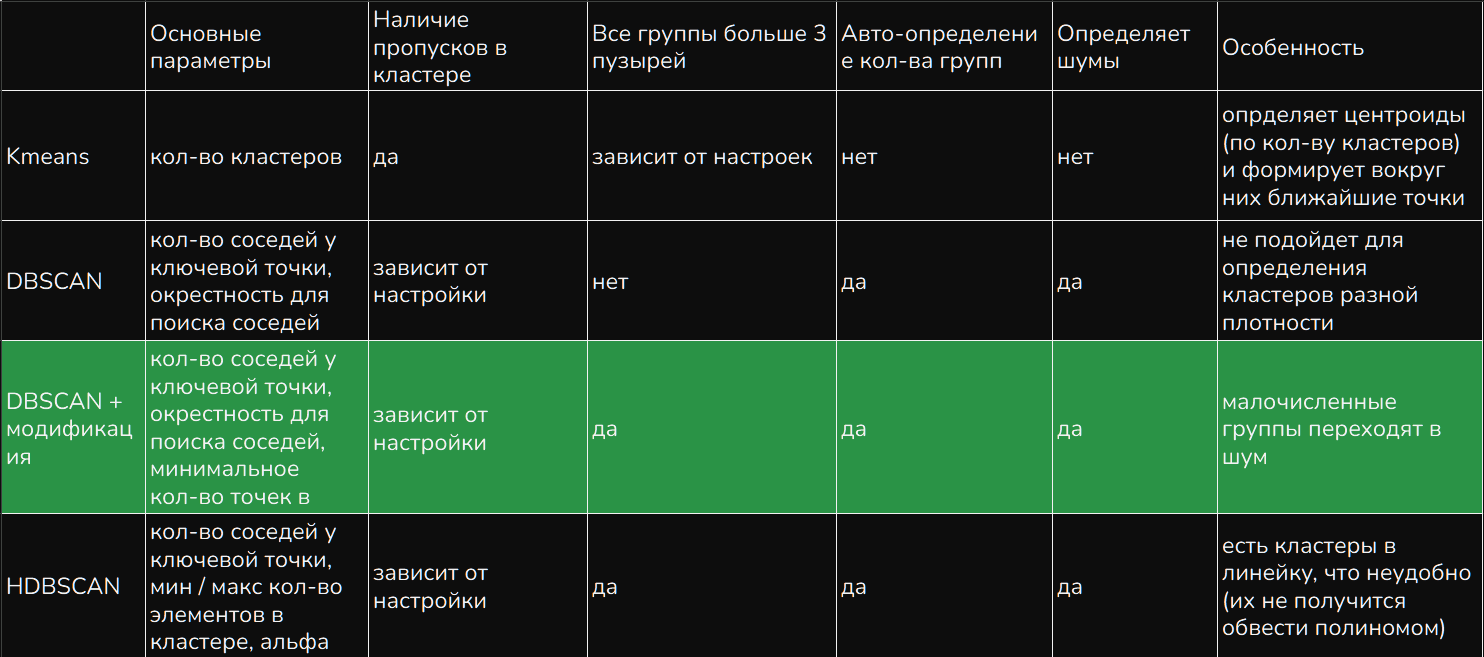

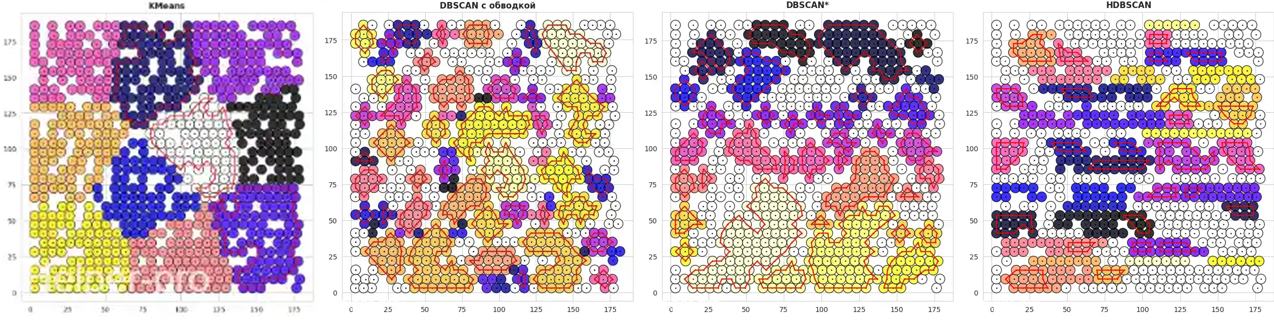

<h3> Перебор параметров </h3>

Закомментировала код, который выдает полотнище графиков для грамотного подбора параметров

```
# Строю графики для оценки модели
cur_n, cur_m, cur_r = 25, 25, 3
# кол-во строк, стобцов
cur_strs, cur_cols = 5, 5
# создаю пространства для нескольких графиков
figure, axis = plt.subplots(5, 5, figsize=(cur_n / 4 * cur_strs,
                                           cur_m / 4 * cur_cols))
# координата строки
cnt = 0
figure.suptitle("Оценка DBSCAN (min_samples=5)")
for i in range(10, 60, 10):
    # генерация новой сетки
    new_xs, new_ys, new_data, new_dots = build_net(cur_n, cur_m, cur_r,
                                                   0.1 * cur_r, i)
    # координата столбца
    j = 0
    # здесь перебираю коэффициенты для расстояний
    for cur_coef in np.linspace(2.2, 2.34, cur_cols):
        # запускаю DBSCAN с текущим настройками, фиксировано мин. кол-во
        #       элементов в кластере
        clusters = DBSCAN(eps=cur_r * cur_coef, min_samples=5).fit(new_dots)
        # отрисовать круги
        axis[cnt, j].scatter(new_xs, new_ys, s=3 *conv_coef,
                             marker=".", linewidths=1, alpha=0.8,
                             c=clusters.labels_, edgecolor='black',
                             cmap="gnuplot2_r")
        # расставить точки
        axis[cnt, j].scatter(new_xs, new_ys, c="black", s=1)
        # установить заголовок
        axis[cnt, j].set_title(
            f"cur_coef={cur_coef}, p={i}, q={len(set(clusters.labels_))}"
            )
        j += 1
    cnt += 1
plt.savefig("посмотрим.png")
```



# <h2> Функции для характеристики кластера </h2>

In [24]:
# функция для характеристики групп стат. метриками
def get_stats_of_cluster(dots: np.ndarray, groups_info: np.ndarray,
                         group_id: int) -> np.ndarray:
    """ Return statistics metric for cluster with number=group_id

    Parameter
    ---------
    dots: np.ndarray
        coordinates with the centers of the circles
    groups_info: np.ndarray
        group number for each dot
    group_id: int
        id of the required group

    Return
    ------
    np.ndarray
        tuple(group id, quantity of dots in the group, mean of the distances,
        root of dispersion for distances, dispersion for distances)
    """
    # точки, попадающие в группу
    g_dots = get_group_info(dots, groups_info, group_id,
                                       return_indexes=False)

    # посчитать расстояния между каждой точкой
    # на вход 2 массива: берем и соединяем каждый 1-ого массива
    #       с каждым элементов 2-ого массива
    distances = cdist(g_dots, g_dots, 'euclidean')
    # на выходе двумерный массив с расстояними

    # кол-во элементов в полученной матрице
    n = len(g_dots)
    # считаем уникальные расстояния - тут трюк с верхним треугольником
    # верхний треугольник в квадратной матрице - все, что выше главной диагонали
    unique_distances = distances[np.triu_indices(n, k=1)]
    # среднее
    dist_mean = np.mean(unique_distances)
    # долгожданная дисперсия
    dist_var = np.var(unique_distances)
    # СКО
    dist_std = np.std(unique_distances)
    return group_id, n, dist_mean, dist_std, dist_var

In [25]:
# считаем площадь покрытия внутри кластера по group_id
def get_area_for_cluster(dots: np.ndarray, groups_info: np.ndarray,
                         group_id: int, lower_border: int=4,
                         shape_alpha: float=0.2, optimize: bool=False,
                         to_expand_dots: bool=False, r_val: float=0) -> float:
    """ Return the area of the cluster with number = group_id
    See get_polygon_for_cluster description
    """
    pol = get_polygon_for_cluster(dots, groups_info, group_id,
                                  lower_border=lower_border,
                                  shape_alpha=shape_alpha, optimize=optimize,
                                  to_expand_dots=to_expand_dots, r_val=r_val)
    if pol is None:
        return None
    return pol.area

In [26]:
# искусственно исключить группы, не попадающе в список
def to_exclude_groups(dots: np.ndarray, groups_info: np.ndarray,
                      groups_to_save: list, val: int=-1) -> np.ndarray:
    """ Return fixed array with values of the groups, which are in
            groups_to_save, other groups'll be marked as noises

    Parameter
    ---------
    dots: np.ndarray
        coordinates with the centers of the circles
    groups_info: np.ndarray
        array with number of group for each dot
    groups_to_save: np.ndarray
        array with numbers of the groups, that we want to leave
    val: int
        marker of noise

    Return
    ------
    np.ndarray
        fixed group numbers, which contains only from groups_to_save
    """

    # отбор индексов из групп для отрисовки
    needed_indexes = []
    for id in groups_to_save:
        needed_indexes += get_group_info(dots, groups_info, id)

    excluded_indexes = set(range(len(dots))) - set(needed_indexes)
    # пока перекраиваю под шум, то, что не нужно отображать
    new_groups = groups_info.copy()
    for exclude_index in excluded_indexes:
        new_groups[exclude_index] = val
    return new_groups

In [27]:
def get_stats_from_group_ids(dots: np.ndarray, clusters: np.ndarray,
                             return_processed: bool=False) -> list:
    """ Return stats for required group ids (which are in clusters)

    Parameter
    ---------
    dots: np.ndarray
        coordinates with centers of the circles
    cluster: np.ndarray
        array with number of the group for each dot
    return_processed: bool
        control type of output
        if switched: output is list with labels
        else: return raw stats in tuple

    Return
    ------
    list
        depends on return_processed
    """
    # этот текст для легенды
    def get_stat_text(stat_val):
        legend_text = (
            f"{stat_val[0]} (n={stat_val[1]}): r̄={stat_val[2]:.2f}, "
            f"μ={stat_val[3]:.2f}, σ²={stat_val[4]:.2f}"
        )
        return legend_text

    all_stats = list(map(lambda id: get_stats_of_cluster(dots, clusters, id),
                    np.unique(clusters)))

    if return_processed:
        legend_info = list(map(
            lambda current_stat: get_stat_text(current_stat),
            all_stats
            ))
        return legend_info
    return all_stats

/tmp/ipython-input-7-1279800378.py:33: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(xs, ys, s=R *conv_coef, marker=".", linewidths=1,


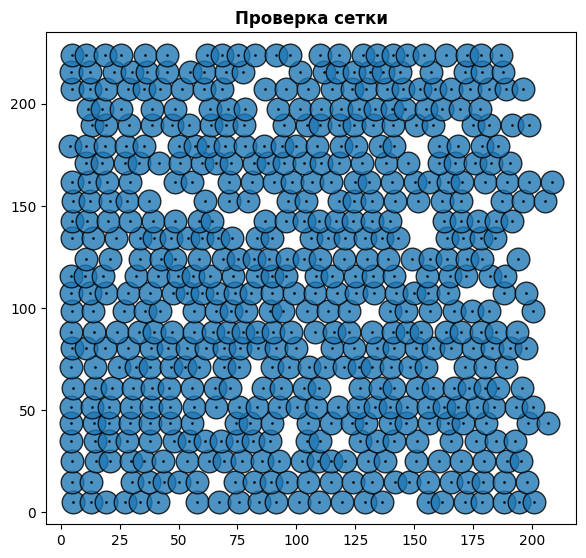

In [28]:
cur_k, cur_l, cur_r = 25, 25, 4
new_dots = build_net(cur_k, cur_l, cur_r, cur_r * 0.3, 10)
show_net(new_dots, cur_r, "Проверка сетки")

In [29]:
dbscan_predictions = get_dbscan_prediction(new_dots, 2.4 * cur_r, 5, modificated=True)
check_preds = np.copy(dbscan_predictions)

In [30]:
# это создание словаря с легендами
legend_info = get_stats_from_group_ids(new_dots, dbscan_predictions,
                                       return_processed=True)
group_id_with_legend = dict()
for element in legend_info:
    group_id = int(element[: element.index(" ")])
    group_id_with_legend[group_id] = element
group_id_with_legend[-1]

'-1 (n=315): r̄=117.29, μ=56.30, σ²=3169.46'

<Figure size 640x480 with 0 Axes>

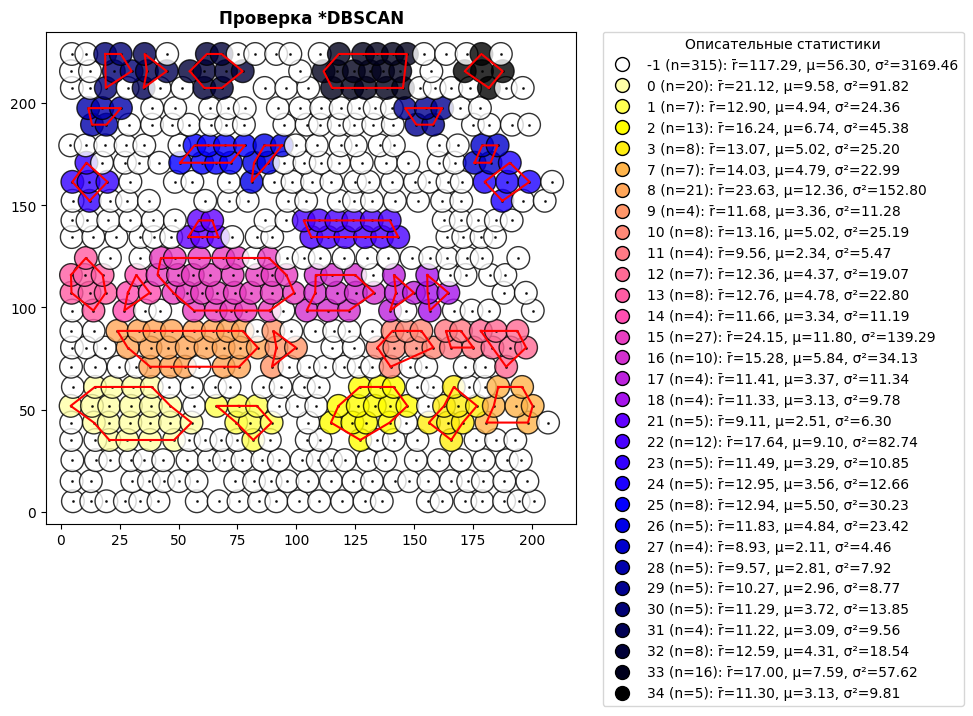

In [31]:
show_net_with_polygons(np.copy(new_dots), cur_r,
                    "Проверка *DBSCAN",
                    bubble_colors=dbscan_predictions, shape_alpha=0.05,
                    legend_dict=group_id_with_legend,
                    legend_tittle="Описательные статистики"
        )

In [32]:
sizes_dict = dict()
for group_id in set(dbscan_predictions):
    area = get_area_for_cluster(new_dots, dbscan_predictions,
                              group_id, optimize=True, to_expand_dots=True)
    n = len(get_group_info(new_dots, dbscan_predictions, group_id))
    if area is None:
        sizes_dict[group_id] = area
        continue
    sizes_dict[group_id] = f"{group_id}(n={n}) {np.round(area, 4)}"
sizes_dict[0]

'0(n=20) 943.8404'

In [33]:
type(new_dots)

numpy.ndarray

<Figure size 640x480 with 0 Axes>

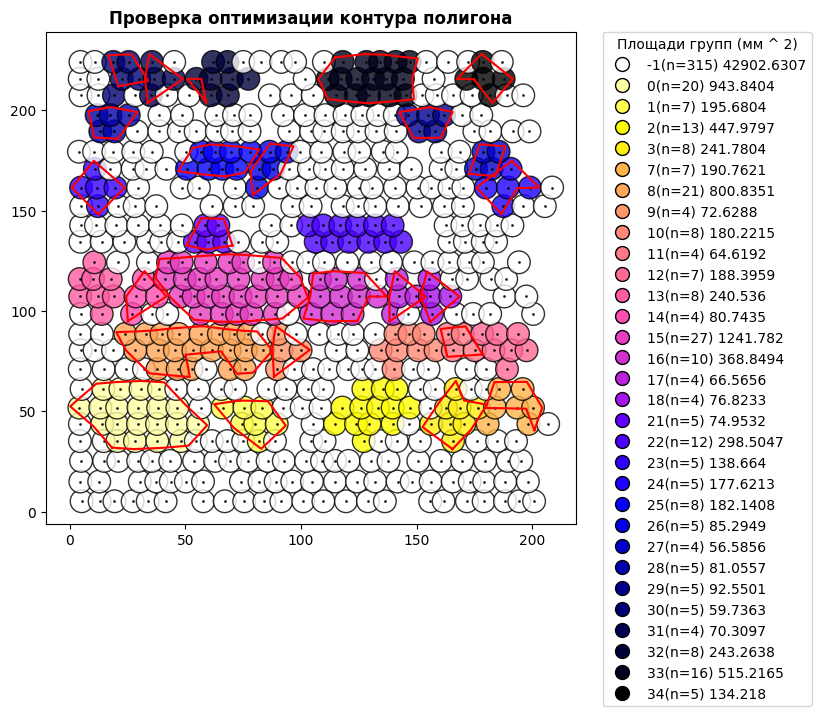

In [34]:
show_net_with_polygons(np.copy(new_dots), cur_r,
                    "Проверка оптимизации контура полигона",
                    bubble_colors=dbscan_predictions, optimize=True,
                    to_expand_dots=True,
                    legend_dict=sizes_dict,
                    legend_tittle="Площади групп (мм ^ 2)"
        )

In [35]:
raw_sizes_dict = dict()
for group_id in set(dbscan_predictions):
    area = get_area_for_cluster(new_dots, dbscan_predictions,
                              group_id, optimize=True, to_expand_dots=False)
    n = len(get_group_info(new_dots, dbscan_predictions, group_id))
    if area is None:
        raw_sizes_dict[group_id] = None
    else:
        raw_sizes_dict[group_id] = f"{group_id}(n={n}) {np.round(area, 4)}"
raw_sizes_dict[0]

'0(n=20) 943.8404'

<Figure size 640x480 with 0 Axes>

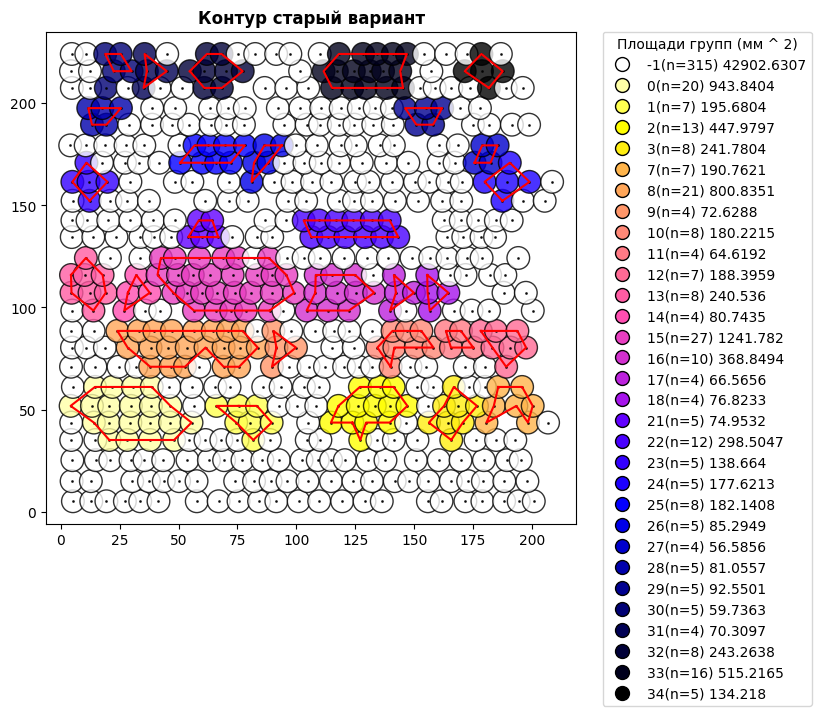

In [36]:
show_net_with_polygons(np.copy(new_dots), cur_r,
                    "Контур старый вариант",
                    bubble_colors=dbscan_predictions, optimize=True,
                    to_expand_dots=False,
                    legend_dict=raw_sizes_dict,
                    legend_tittle="Площади групп (мм ^ 2)"
        )

# Заготовка для графика

In [37]:
# пример детализированного гарфика
def show_detailed_plot(xs: np.ndarray, ys: np.ndarray, title: str="",
                       x_lab: str="", y_lab: str=""):
    # тело графика
    sns.lineplot(x=xs, y=ys, label="$E_p$ = mgh")
    # стиль сетки
    sns.set_style("whitegrid")
    # заголовок
    plt.title(title, weight="bold", pad=10)
    # подписываем оси и не забываем про единицы измерения
    plt.xlabel(x_lab)
    plt.ylabel(y_lab)
    # настройка эстетичной сетки
    plt.grid(True, linestyle="--")
    # для примера вертикальные линии
    plt.axvline(x=1.5, alpha=0.5, label="Сжатие", color="b")
    plt.axvline(x=4.5, alpha=0.5, label="Растяжение", color="r")
    # +- по-умному выделяю пространство у прямой
    plt.fill_between(test_xs, ys - 0.4, ys + 0.4,
                 color='#787cfa79', label="погрешность")
    # размещение легенды
    plt.legend(title="Текст легенды", borderpad=1.5, loc="lower right")

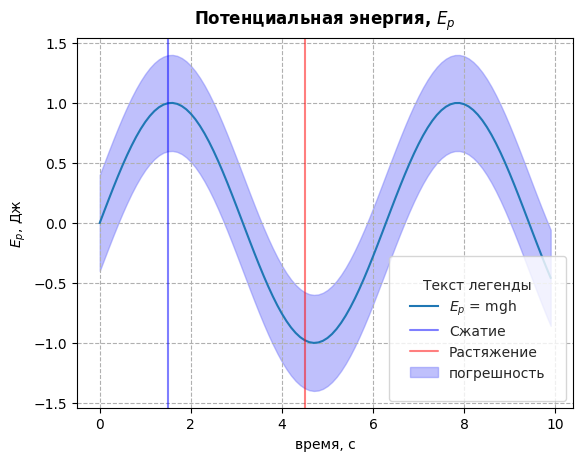

In [38]:
test_xs = np.arange(0, 10, 0.1)
test_ys = np.sin(test_xs)
show_detailed_plot(test_xs, test_ys, title="Потенциальная энергия, $E_p$",
                    x_lab="время, с",
                    y_lab="$E_p$, Дж",
                   )